In [39]:
import tensorflow_datasets as tfd
import tensorflow as tf
data = tfd.load("imdb_reviews", as_supervised = True)

In [40]:
print (data)
train, test = data["train"], data["test"]


{'train': <_PrefetchDataset element_spec=(TensorSpec(shape=(), dtype=tf.string, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>, 'test': <_PrefetchDataset element_spec=(TensorSpec(shape=(), dtype=tf.string, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>, 'unsupervised': <_PrefetchDataset element_spec=(TensorSpec(shape=(), dtype=tf.string, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>}


In [41]:
# To access elements, you can iterate through the dataset
# for example in test.take(5): # Take the first 5 examples
#   print(example)

# If you need to access a specific element by index after iterating, you can convert the dataset to a list (for smaller datasets)
train_list = list(train.as_numpy_iterator())
print(train_list[1])

(b'I have been known to fall asleep during films, but this is usually due to a combination of things including, really tired, being warm and comfortable on the sette and having just eaten a lot. However on this occasion I fell asleep because the film was rubbish. The plot development was constant. Constantly slow and boring. Things seemed to happen, but with no explanation of what was causing them or why. I admit, I may have missed part of the film, but i watched the majority of it and everything just seemed to happen of its own accord without any real concern for anything else. I cant recommend this film at all.', np.int64(0))


In [42]:
# Preprocess: chuyển từ tensor về list để lấy
train_sentences = []
train_labels = []
test_sentences = []
test_labels = []
for i,j in train:
  train_sentences.append(i.numpy().decode("utf8"))
  train_labels.append (j.numpy())

for i,j in test:
  test_sentences.append(i.numpy().decode("utf8"))
  test_labels.append (j.numpy())

In [43]:
print (train_sentences[1])
print (train_labels[1])

I have been known to fall asleep during films, but this is usually due to a combination of things including, really tired, being warm and comfortable on the sette and having just eaten a lot. However on this occasion I fell asleep because the film was rubbish. The plot development was constant. Constantly slow and boring. Things seemed to happen, but with no explanation of what was causing them or why. I admit, I may have missed part of the film, but i watched the majority of it and everything just seemed to happen of its own accord without any real concern for anything else. I cant recommend this film at all.
0


In [44]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Tokenize văn bản
vocab_size = 10000 # Để None nếu muốn lấy toàn bộ từ, để càng cao càng dễ bị overfit
oov_token = "<OOV>" # token cho từ ngoài từ điển

tokenizer = Tokenizer(num_words = vocab_size, oov_token = oov_token)
tokenizer.fit_on_texts(train_sentences) # fit trên tập train

train_sequences = tokenizer.texts_to_sequences(train_sentences) # Chuyển chuỗi văn bản thành các chuỗi số nguyên (token id)
test_sequences = tokenizer.texts_to_sequences(test_sentences)

In [45]:
print (train_sequences[0])

[12, 14, 33, 425, 392, 18, 90, 28, 1, 9, 32, 1366, 3585, 40, 486, 1, 197, 24, 85, 154, 19, 12, 213, 329, 28, 66, 247, 215, 9, 477, 58, 66, 85, 114, 98, 22, 5675, 12, 1322, 643, 767, 12, 18, 7, 33, 400, 8170, 176, 2455, 416, 2, 89, 1231, 137, 69, 146, 52, 2, 1, 7577, 69, 229, 66, 2933, 16, 1, 2904, 1, 1, 1479, 4940, 3, 39, 3900, 117, 1584, 17, 3585, 14, 162, 19, 4, 1231, 917, 7917, 9, 4, 18, 13, 14, 4139, 5, 99, 145, 1214, 11, 242, 683, 13, 48, 24, 100, 38, 12, 7181, 5515, 38, 1366, 1, 50, 401, 11, 98, 1197, 867, 141, 10]


In [46]:
# Padding + truncating (cắt)
max_length = 256 # Độ dài token tối đa của câu
# Câu dài hơn thì truncate, câu ngắn hơn thì pad
trunc_type = "post"
padding_type = "post"
train_padded = pad_sequences(train_sequences, maxlen=max_length, padding= padding_type, truncating=trunc_type)
test_padded = pad_sequences(test_sequences, maxlen=max_length, padding= padding_type, truncating=trunc_type)


In [47]:
print (len(train_padded[0]))

256


In [48]:
import numpy as np
# Chuyển label từ list sang numpy
train_labels = np.array(train_labels)
test_labels = np.array(test_labels)


In [49]:
print("Train padded shape:", train_padded.shape)
print("First sample (tokens shape:", train_padded[0].shape)
print("First sample (tokens):", train_padded[0])
print("First label:", train_labels[0])


Train padded shape: (25000, 256)
First sample (tokens shape: (256,)
First sample (tokens): [  12   14   33  425  392   18   90   28    1    9   32 1366 3585   40
  486    1  197   24   85  154   19   12  213  329   28   66  247  215
    9  477   58   66   85  114   98   22 5675   12 1322  643  767   12
   18    7   33  400 8170  176 2455  416    2   89 1231  137   69  146
   52    2    1 7577   69  229   66 2933   16    1 2904    1    1 1479
 4940    3   39 3900  117 1584   17 3585   14  162   19    4 1231  917
 7917    9    4   18   13   14 4139    5   99  145 1214   11  242  683
   13   48   24  100   38   12 7181 5515   38 1366    1   50  401   11
   98 1197  867  141   10    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0  

In [58]:
from tensorflow.keras import layers
from tensorflow.keras import regularizers
l2_lambda = 0.001
# Tạo model train, test
model = tf.keras.Sequential([
    layers.Embedding(input_dim=vocab_size, output_dim=64),
    layers.Bidirectional(layers.LSTM(64, kernel_regularizer=regularizers.l2(l2_lambda))), # LSTM hoặc GRU
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(l2_lambda)),
    layers.Dense(1, activation = 'sigmoid', kernel_regularizer=regularizers.l2(l2_lambda))
])

model.compile(loss='binary_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

In [59]:
history = model.fit(train_padded, train_labels, epochs=4, batch_size = 64, validation_data=(test_padded, test_labels))
model.summary()

Epoch 1/4
391/391 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.6442 - loss: 0.6999 - val_accuracy: 0.7968 - val_loss: 0.4709
Epoch 2/4
391/391 ━━━━━━━━━━━━━━━━━━━━ 18s 30ms/step - accuracy: 0.8624 - loss: 0.3693 - val_accuracy: 0.8489 - val_loss: 0.3639
Epoch 3/4
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - accuracy: 0.9110 - loss: 0.2652 - val_accuracy: 0.8501 - val_loss: 0.3626
Epoch 4/4
391/391 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - accuracy: 0.9285 - loss: 0.2197 - val_accuracy: 0.8143 - val_loss: 0.4414


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ (None, 256, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ (None, 128)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,143,109 (8.18 MB)

 Trainable params: 714,369 (2.73 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,428,740 (5.45 MB)

In [ ]:
# Lớp bidirectional có 66 048 tham số do:
# - đầu vào có chiều 64 (256 là độ dài)
# [64 chiều x 64 unit](weight) + 64 (bias) + [64 chiều x 64 unit ](hidden state) = 8256
# Có 4 bộ như vậy do có 4 cổng input, output, forget, cell gate nên 4 x 8256 = 33024 tham số
# Bidirectional nên 2 x 33024 = 66048 tham số tất cả

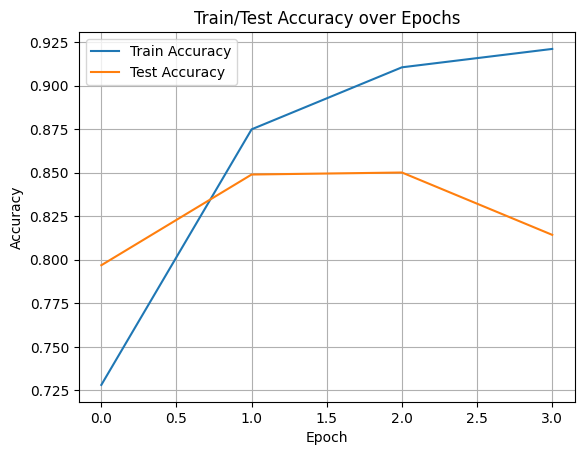

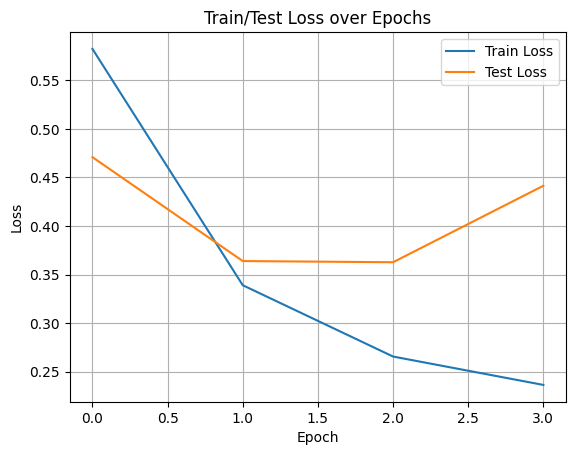

In [60]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Train/Test Accuracy over Epochs')
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train/Test Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()

782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step


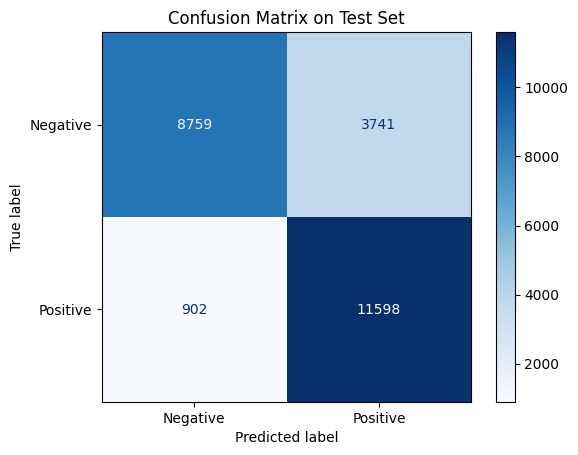

In [61]:
# Tạo confusion matrix
# Dự đoán xác suất (sigmoid output)
pred_probs = model.predict(test_padded)

# Chuyển thành nhãn nhị phân (0 hoặc 1)
pred_labels = (pred_probs > 0.5).astype("int32").flatten()

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(test_labels, pred_labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix on Test Set")
plt.grid(False)
plt.show()


In [ ]:
### Overfit.